#### Обработка пропусков

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [2]:
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
data.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [4]:
data.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((891, 15), (891, 11))

In [6]:
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((891, 15), (182, 15))

In [7]:
# Выберем числовые колонки с пропущенными значениями
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    total_count = data[col].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка age. Тип данных float64. Количество пустых значений 177, 19.87%.


In [8]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [9]:
data_num_age = data_num[['age']]
data_num_age.head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [10]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [11]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_age)

In [12]:
strategies=['mean', 'median', 'most_frequent']

def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_age)
    return data_num_imp[mask_missing_values_only]

In [13]:
print(strategies[0], set(test_num_impute(strategies[0])))
print(strategies[1], set(test_num_impute(strategies[1])))
print(strategies[2], set(test_num_impute(strategies[2])))

mean {np.float64(29.69911764705882)}
median {np.float64(28.0)}
most_frequent {np.float64(24.0)}


In [14]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    total_count = data[col].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='category' or dt=='str'):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка embarked. Тип данных str. Количество пустых значений 2, 0.22%.
Колонка deck. Тип данных category. Количество пустых значений 688, 77.22%.
Колонка embark_town. Тип данных str. Количество пустых значений 2, 0.22%.


In [15]:
cat_temp_data = data[['embarked']]
cat_temp_data.head()

,embarked
0,S
1,C
2,S
3,S
4,S


In [16]:
cat_temp_data['embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [17]:
# Импьютация наиболее частыми значениями
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)

# Пустые значения отсутствуют
np.unique(data_imp2)

array(['C', 'Q', 'S'], dtype=object)

#### Преобразование категориальных признаков в числовые

In [18]:
cat_enc = pd.DataFrame({'c1':data_imp2.T[0]})
cat_enc['c1'].unique()

<ArrowStringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [19]:
#Использование LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

le.classes_

array(['C', 'Q', 'S'], dtype=object)

In [20]:
np.unique(cat_enc_le)

array([0, 1, 2])

In [22]:
#Использование OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

data_oe = data[['embarked', 'deck', 'embark_town']]
data_oe.head()

,embarked,deck,embark_town
0,S,NaN,Southampton
1,C,C,Cherbourg
2,S,NaN,Southampton
3,S,C,Southampton
4,S,NaN,Southampton


In [23]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['S', 'NA', 'Southampton'],
       ['C', 'C', 'Cherbourg'],
       ['S', 'NA', 'Southampton'],
       ...,
       ['S', 'NA', 'Southampton'],
       ['C', 'C', 'Cherbourg'],
       ['Q', 'NA', 'Queenstown']], shape=(891, 3), dtype=object)

In [24]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[3., 7., 3.],
       [0., 2., 0.],
       [3., 7., 3.],
       ...,
       [3., 7., 3.],
       [0., 2., 0.],
       [2., 7., 2.]], shape=(891, 3))

In [25]:
print(np.unique(cat_enc_oe[:, 0]))
print(np.unique(cat_enc_oe[:, 1]))
print(np.unique(cat_enc_oe[:, 2]))

[0. 1. 2. 3.]
[0. 1. 2. 3. 4. 5. 6. 7.]
[0. 1. 2. 3.]


In [27]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['C', 'NA', 'Q', 'S'], dtype=object),
 array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'NA'], dtype=object),
 array(['Cherbourg', 'NA', 'Queenstown', 'Southampton'], dtype=object)]

In [28]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['S', 'NA', 'Southampton'],
       ['C', 'C', 'Cherbourg'],
       ['S', 'NA', 'Southampton'],
       ...,
       ['S', 'NA', 'Southampton'],
       ['C', 'C', 'Cherbourg'],
       ['Q', 'NA', 'Queenstown']], shape=(891, 3), dtype=object)

#### Масштабирование данных

In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

In [35]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['fare']])

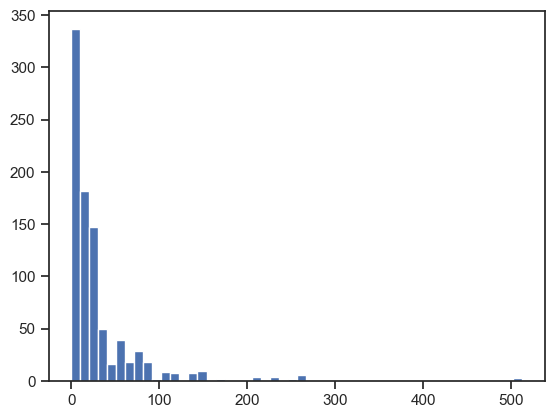

In [42]:
plt.hist(data['fare'], 50)
plt.show()

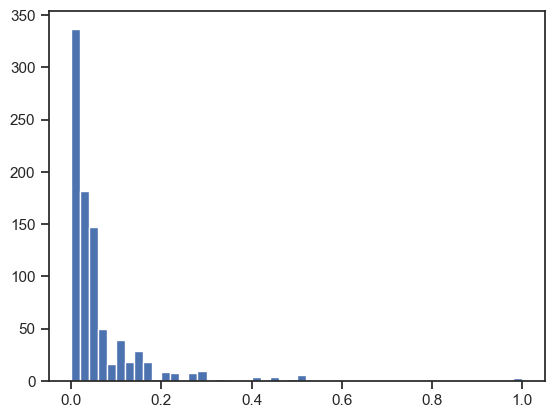

In [43]:
plt.hist(sc1_data, 50)
plt.show()

In [44]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['fare']])

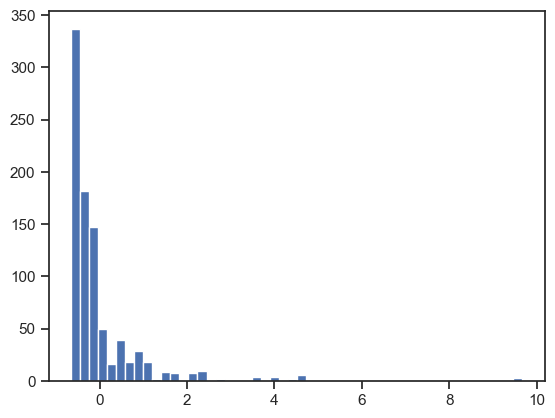

In [45]:
plt.hist(sc2_data, 50)
plt.show()